# Tourism Project Analytics: Classification, prediction and Recommendation System

## 1. Data Cleaning

### A. Install and Imports

In [1]:
## Install & imports
!pip -q install duckdb streamlit pyngrok joblib scikit-learn pandas numpy matplotlib
!pip -q install scikit-learn==1.6.1



In [2]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics.pairwise import cosine_similarity

import duckdb
import joblib

### B. Load the data files

In [3]:
## Mount Google Drive & set project folder
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

# List top-level items in MyDrive
os.listdir('/content/drive/MyDrive/tourism_project/data')

['City.xlsx',
 'Continent.xlsx',
 'Country.xlsx',
 'Item.xlsx',
 'Mode.xlsx',
 'Region.xlsx',
 'Transaction.xlsx',
 'Type.xlsx',
 'User.xlsx',
 'Updated_Item.xlsx',
 'Continent.csv',
 'Region.csv',
 'Mode.csv',
 'Country.csv',
 'City.csv',
 'Item.csv',
 'Transaction.csv',
 'Type.csv',
 'Updated_Item.csv',
 'User.csv']

In [5]:
# CHANGE THIS PATH to your folder containing all CSVs
DATA_DIR = "/content/drive/MyDrive/tourism_project/data"

In [6]:
## Convert xlsx files to csv
import os, glob
import pandas as pd

xlsx_files = glob.glob(os.path.join(DATA_DIR, "*.xlsx"))

for f in xlsx_files:
    df_tmp = pd.read_excel(f, engine="openpyxl")
    csv_name = os.path.splitext(os.path.basename(f))[0] + ".csv"
    out_path = os.path.join(DATA_DIR, csv_name)
    df_tmp.to_csv(out_path, index=False)
    print("Saved:", out_path)

Saved: /content/drive/MyDrive/tourism_project/data/City.csv
Saved: /content/drive/MyDrive/tourism_project/data/Continent.csv
Saved: /content/drive/MyDrive/tourism_project/data/Country.csv
Saved: /content/drive/MyDrive/tourism_project/data/Item.csv
Saved: /content/drive/MyDrive/tourism_project/data/Mode.csv
Saved: /content/drive/MyDrive/tourism_project/data/Region.csv
Saved: /content/drive/MyDrive/tourism_project/data/Transaction.csv
Saved: /content/drive/MyDrive/tourism_project/data/Type.csv
Saved: /content/drive/MyDrive/tourism_project/data/User.csv
Saved: /content/drive/MyDrive/tourism_project/data/Updated_Item.csv


In [7]:
## Load All Tables
FILE_MAP = {
    "transactions": ["Transaction.csv"],
    "users": ["User.csv"],
    "cities": ["City.csv"],
    "items": ["Item.csv"],
    "types": ["Type.csv"],
    "visit_modes": ["Mode.csv"],
    "continents": ["Continent.csv"],
    "countries": [ "Country.csv"],
    "regions": ["Region.csv"],
}

def find_file(candidates):
    for name in candidates:
        path = os.path.join(DATA_DIR, name)
        if os.path.exists(path):
            return path
    return None

tables = {}
for key, candidates in FILE_MAP.items():
    path = find_file(candidates)
    if path:
        tables[key] = pd.read_csv(path)
        print(f"Loaded {key}: {os.path.basename(path)} | shape={tables[key].shape}")
    else:
        print(f"Missing {key} (ok if your dataset doesn't have it).")

# Quick look at core tables
for k in ["transactions", "users", "items", "cities"]:
    if k in tables:
        print("\n==", k, "==")
        display(tables[k].head())
        print("Columns:", list(tables[k].columns))

Loaded transactions: Transaction.csv | shape=(52930, 7)
Loaded users: User.csv | shape=(33530, 5)
Loaded cities: City.csv | shape=(9143, 3)
Loaded items: Item.csv | shape=(30, 5)
Loaded types: Type.csv | shape=(17, 2)
Loaded visit_modes: Mode.csv | shape=(6, 2)
Loaded continents: Continent.csv | shape=(6, 2)
Loaded countries: Country.csv | shape=(165, 3)
Loaded regions: Region.csv | shape=(22, 3)

== transactions ==


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

== users ==


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


Columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

== items ==


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


Columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

== cities ==


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3


Columns: ['CityId', 'CityName', 'CountryId']


In [8]:
for name, tdf in tables.items():
    print("\n---", name, "---")
    print(tdf.columns.tolist())


--- transactions ---
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

--- users ---
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

--- cities ---
['CityId', 'CityName', 'CountryId']

--- items ---
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

--- types ---
['AttractionTypeId', 'AttractionType']

--- visit_modes ---
['VisitModeId', 'VisitMode']

--- continents ---
['ContinentId', 'Continent']

--- countries ---
['CountryId', 'Country', 'RegionId']

--- regions ---
['Region', 'RegionId', 'ContinentId']


### C. Cleaning the Dataset

In [9]:
## Standardize column names + basic cleaning helpers
def clean_colnames(df):
    df = df.copy()
    df.columns = [c.strip().replace(" ", "").replace("-", "").replace("/", "") for c in df.columns]
    return df

for k in list(tables.keys()):
    tables[k] = clean_colnames(tables[k])

# Helper to safely title-case strings
def safe_title(s):
    return s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True).str.title()

# Clean some likely string columns if present
if "cities" in tables and "CityName" in tables["cities"].columns:
    tables["cities"]["CityName"] = safe_title(tables["cities"]["CityName"])

if "items" in tables:
    for col in ["Attraction", "AttractionAddress"]:
        if col in tables["items"].columns:
            tables["items"][col] = tables["items"][col].astype(str).str.strip()


## 2. Preprocessing

### A. Build the consolidated dataset

In [10]:
# -----------------------------
# Build the consolidated dataset (JOINs)
# -----------------------------

# Required minimum for the project
required = ["transactions", "users", "items"]
for r in required:
    if r not in tables:
        raise ValueError(f"Missing required table: {r}. Please ensure '{r}' exists in tables dict.")

tx    = tables["transactions"].copy()
users = tables["users"].copy()
items = tables["items"].copy()

# Quick schema check
print("Transaction columns:", tx.columns.tolist())
print("User columns:", users.columns.tolist())
print("Item columns:", items.columns.tolist())

# -----------------------------
# Basic type conversions (safe)
# -----------------------------
for col in ["UserId", "AttractionId", "VisitYear", "VisitMonth"]:
    if col in tx.columns:
        tx[col] = pd.to_numeric(tx[col], errors="coerce")

if "Rating" in tx.columns:
    tx["Rating"] = pd.to_numeric(tx["Rating"], errors="coerce")
    tx["Rating"] = tx["Rating"].clip(lower=1, upper=5)

# Drop rows missing essential ids
tx = tx.dropna(subset=["UserId", "AttractionId"])
tx["UserId"] = tx["UserId"].astype(int)
tx["AttractionId"] = tx["AttractionId"].astype(int)

# -----------------------------
# Merge core tables
# -----------------------------
df = tx.merge(users, on="UserId", how="left", suffixes=("", "_user"))
df = df.merge(items, on="AttractionId", how="left", suffixes=("", "_item"))

# -----------------------------
# Add city names (user city + attraction city)
# -----------------------------
if "cities" in tables:
    cities = tables["cities"].copy()

    # Ensure expected columns exist
    if "CityId" in cities.columns and "CityName" in cities.columns:

        # 1) User city name
        if "CityId" in df.columns:
            df = df.merge(
                cities[["CityId", "CityName"]],
                on="CityId",
                how="left"
            ).rename(columns={"CityName": "UserCityName"})

        # 2) Attraction city name
        if "AttractionCityId" in df.columns:
            df = df.merge(
                cities[["CityId", "CityName"]].rename(
                    columns={"CityId": "AttractionCityId", "CityName": "AttractionCityName"}
                ),
                on="AttractionCityId",
                how="left"
            )

# -----------------------------
# Add attraction type name
# -----------------------------
if "types" in tables:
    types = tables["types"].copy()

    # Expect: AttractionTypeId, AttractionType (names may vary slightly)
    if "AttractionTypeId" in df.columns and "AttractionTypeId" in types.columns:
        cols = [c for c in ["AttractionTypeId", "AttractionType"] if c in types.columns]
        if len(cols) == 2:
            df = df.merge(types[cols], on="AttractionTypeId", how="left")

# -----------------------------
# Add visit mode name (FIXED)
# -----------------------------
if "visit_modes" in tables and "VisitMode" in df.columns:
    vm = tables["visit_modes"].copy()

    # Expected: VisitModeId (id) and VisitMode (name)
    if "VisitModeId" in vm.columns and "VisitMode" in vm.columns:

        # If df["VisitMode"] is numeric, map it using lookup
        if pd.api.types.is_numeric_dtype(df["VisitMode"]):
            df = df.merge(
                vm[["VisitModeId", "VisitMode"]].rename(columns={"VisitMode": "VisitModeName"}),
                left_on="VisitMode",
                right_on="VisitModeId",
                how="left"
            )
            df["VisitMode"] = df["VisitModeName"]
            df = df.drop(columns=["VisitModeId", "VisitModeName"])

# -----------------------------
# Done
# -----------------------------
print("Consolidated df shape:", df.shape)
display(df.head())

Transaction columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
User columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
Item columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
Consolidated df shape: (52930, 18)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,UserCityName,AttractionCityName,AttractionType
0,3,70456,2022,10,Couples,640,5,5,21,163,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Guildford,Douala,Nature & Wildlife Areas
1,8,7567,2022,10,Friends,640,5,2,8,48,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Ontario,Douala,Nature & Wildlife Areas
2,9,79069,2022,10,Family,640,5,2,9,54,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Brazil,Douala,Nature & Wildlife Areas
3,10,31019,2022,10,Family,640,3,5,17,135,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Zurich,Douala,Nature & Wildlife Areas
4,15,43611,2022,10,Couples,640,3,5,21,163,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Manchester,Douala,Nature & Wildlife Areas


### B. Handle missing values + feature engineering

In [11]:
## Handle missing values + feature engineering
df = df.copy()

# Fill missing categorical values
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    df[c] = df[c].fillna("Unknown")

# Fill missing numeric values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if c != "Rating":
        df[c] = df[c].fillna(df[c].median())

# User-level features (simple, effective)
if "Rating" in df.columns:
    user_stats = df.groupby("UserId").agg(
        user_rating_count=("Rating", "count"),
        user_rating_mean=("Rating", "mean"),
        user_rating_std=("Rating", "std"),
    ).reset_index()
    user_stats["user_rating_std"] = user_stats["user_rating_std"].fillna(0)
    df = df.merge(user_stats, on="UserId", how="left")

# Attraction-level features
if "Rating" in df.columns:
    item_stats = df.groupby("AttractionId").agg(
        attraction_rating_count=("Rating", "count"),
        attraction_rating_mean=("Rating", "mean"),
    ).reset_index()
    df = df.merge(item_stats, on="AttractionId", how="left")

print("After feature engineering:", df.shape)
display(df.head())

out_path = "/content/drive/MyDrive/tourism_project/data/master_cleaned.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path)

After feature engineering: (52930, 23)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,...,Attraction,AttractionAddress,UserCityName,AttractionCityName,AttractionType,user_rating_count,user_rating_mean,user_rating_std,attraction_rating_count,attraction_rating_mean
0,3,70456,2022,10,Couples,640,5,5,21,163,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Guildford,Douala,Nature & Wildlife Areas,1,5.0,0.0,13198,4.267086
1,8,7567,2022,10,Friends,640,5,2,8,48,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Ontario,Douala,Nature & Wildlife Areas,1,5.0,0.0,13198,4.267086
2,9,79069,2022,10,Family,640,5,2,9,54,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Brazil,Douala,Nature & Wildlife Areas,1,5.0,0.0,13198,4.267086
3,10,31019,2022,10,Family,640,3,5,17,135,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Zurich,Douala,Nature & Wildlife Areas,2,3.0,0.0,13198,4.267086
4,15,43611,2022,10,Couples,640,3,5,21,163,...,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Manchester,Douala,Nature & Wildlife Areas,3,3.0,1.0,13198,4.267086


Saved: /content/drive/MyDrive/tourism_project/data/master_cleaned.csv


## 3. Exploratory Data Analysis (EDA)

### U — Univariate charts

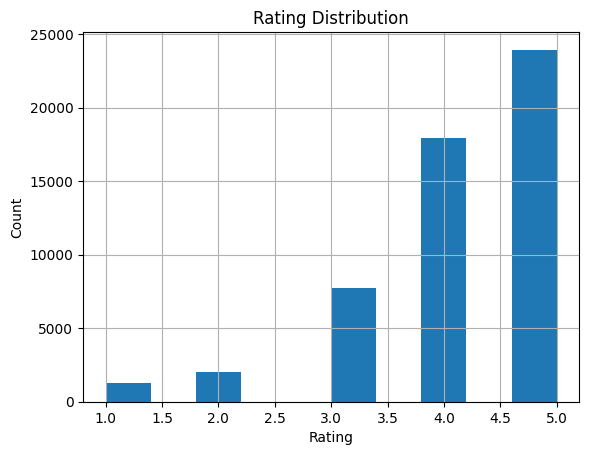

In [12]:
## 1. Rating distribution (hist)
if "Rating" in df.columns:
    plt.figure()
    df["Rating"].dropna().hist(bins=10)
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

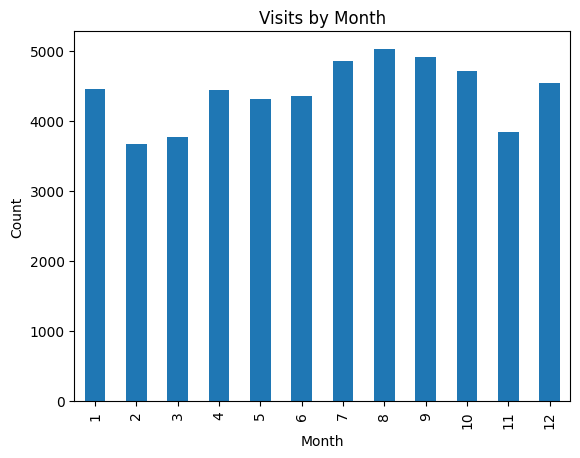

In [13]:
## 2. VisitMonth distribution (bar)
if "VisitMonth" in df.columns:
    counts = df["VisitMonth"].dropna().astype(int).value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title("Visits by Month")
    plt.xlabel("Month")
    plt.ylabel("Count")

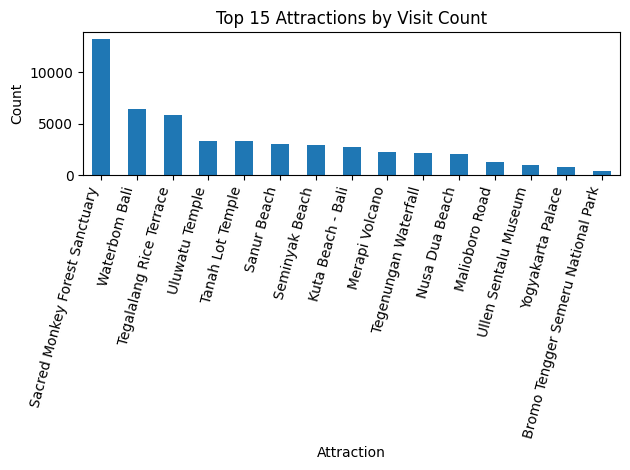

In [14]:
## 3. Top Attractions (bar)
if "Attraction" in df.columns:
    top_attr = df["Attraction"].value_counts().head(15)
    plt.figure()
    top_attr.plot(kind="bar")
    plt.title("Top 15 Attractions by Visit Count")
    plt.xlabel("Attraction")
    plt.ylabel("Count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

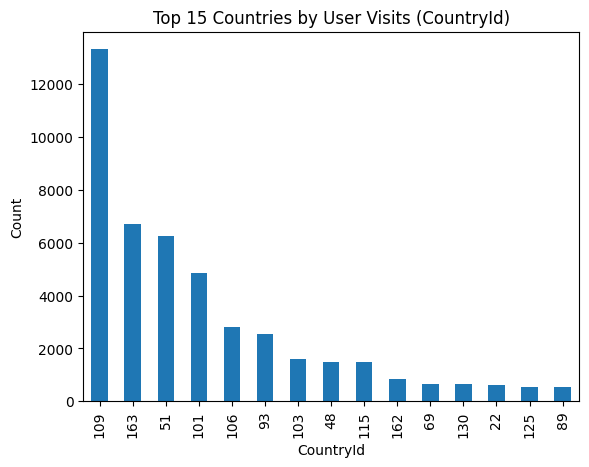

In [15]:
## 4. Users per Country (bar)
if "CountryId" in df.columns:
    top_c = df["CountryId"].value_counts().head(15)
    plt.figure()
    top_c.plot(kind="bar")
    plt.title("Top 15 Countries by User Visits (CountryId)")
    plt.xlabel("CountryId")
    plt.ylabel("Count")
    plt.show()

## B — Bivariate charts

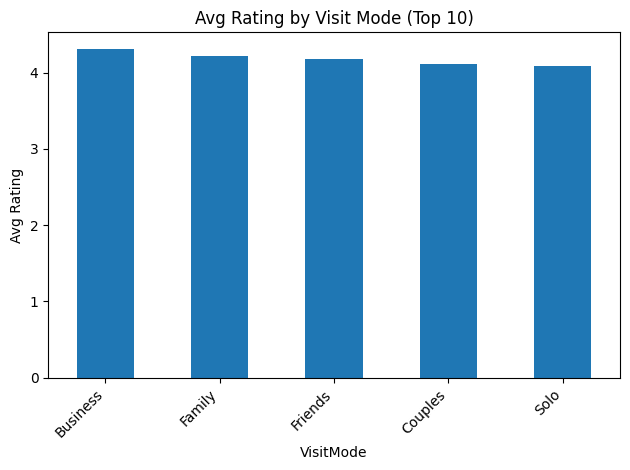

In [16]:
## 5. Average Rating by VisitMode (bar)
if "VisitMode" in df.columns and "Rating" in df.columns:
    tmp = df.dropna(subset=["VisitMode", "Rating"]).groupby("VisitMode")["Rating"].mean().sort_values(ascending=False).head(10)
    plt.figure()
    tmp.plot(kind="bar")
    plt.title("Avg Rating by Visit Mode (Top 10)")
    plt.xlabel("VisitMode")
    plt.ylabel("Avg Rating")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

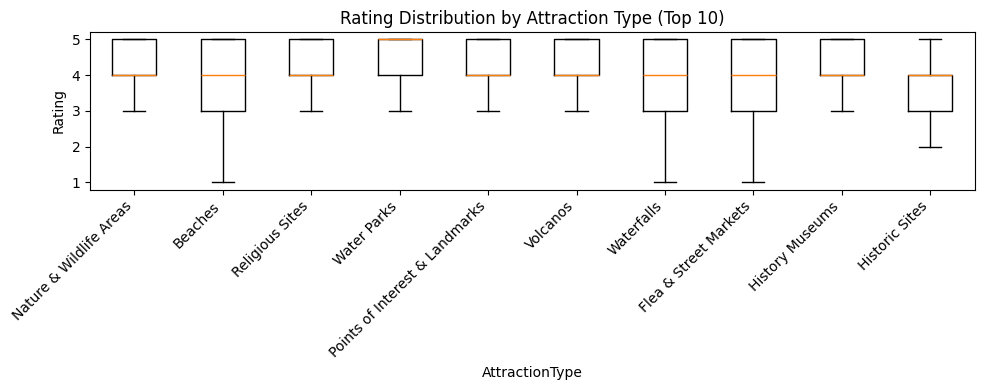

In [17]:
## 6. Rating by AttractionType (boxplot – top 10 types)
if "AttractionType" in df.columns and "Rating" in df.columns:
    top_types = df["AttractionType"].value_counts().head(10).index
    sub = df[df["AttractionType"].isin(top_types)].dropna(subset=["AttractionType", "Rating"])

    labels = []
    data = []
    for t in top_types:
        vals = sub.loc[sub["AttractionType"] == t, "Rating"].values
        if len(vals) > 0:
            labels.append(str(t))
            data.append(vals)

    if len(data) > 0:
        plt.figure(figsize=(10,4))
        plt.boxplot(data, labels=labels, showfliers=False)
        plt.title("Rating Distribution by Attraction Type (Top 10)")
        plt.xlabel("AttractionType")
        plt.ylabel("Rating")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

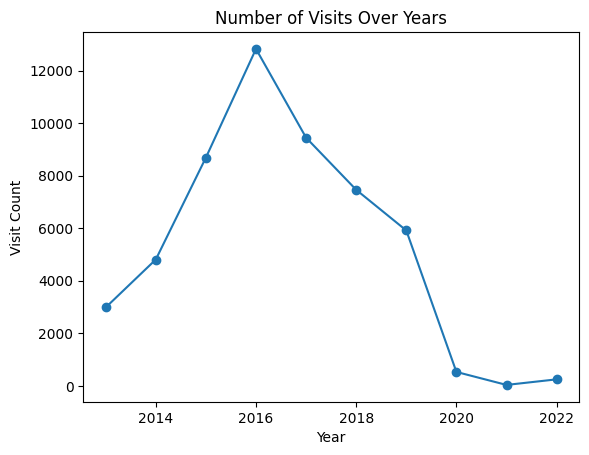

In [18]:
## 7. Visits over Year (line)
if "VisitYear" in df.columns:
    yearly = df["VisitYear"].dropna().astype(int).value_counts().sort_index()
    plt.figure()
    plt.plot(yearly.index, yearly.values, marker="o")
    plt.title("Number of Visits Over Years")
    plt.xlabel("Year")
    plt.ylabel("Visit Count")
    plt.show()

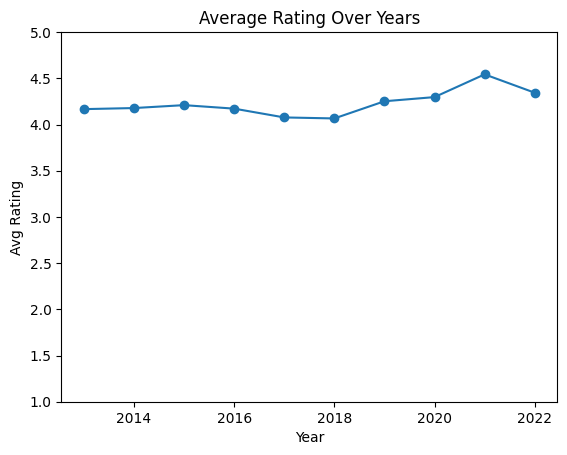

In [19]:
## 8. Avg Rating by Year (line)
if "VisitYear" in df.columns and "Rating" in df.columns:
    yr = df.dropna(subset=["VisitYear","Rating"]).copy()
    yr["VisitYear"] = yr["VisitYear"].astype(int)
    tmp = yr.groupby("VisitYear")["Rating"].mean().sort_index()

    plt.figure()
    plt.plot(tmp.index, tmp.values, marker="o")
    plt.title("Average Rating Over Years")
    plt.xlabel("Year")
    plt.ylabel("Avg Rating")
    plt.ylim(1, 5)
    plt.show()

## M — Multivariate charts

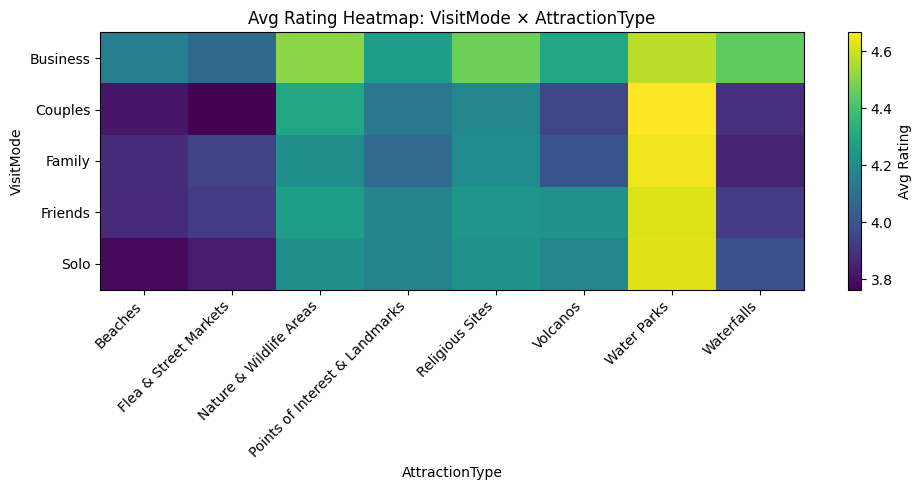

In [20]:
## 9. Heatmap: Avg Rating by (VisitMode × AttractionType) (top 8×8)
if "VisitMode" in df.columns and "AttractionType" in df.columns and "Rating" in df.columns:
    top_vm = df["VisitMode"].value_counts().head(8).index
    top_at = df["AttractionType"].value_counts().head(8).index

    sub = df[df["VisitMode"].isin(top_vm) & df["AttractionType"].isin(top_at)].dropna(subset=["Rating"])
    pivot = sub.pivot_table(index="VisitMode", columns="AttractionType", values="Rating", aggfunc="mean")

    plt.figure(figsize=(10,5))
    plt.imshow(pivot.values, aspect="auto")
    plt.title("Avg Rating Heatmap: VisitMode × AttractionType")
    plt.xlabel("AttractionType")
    plt.ylabel("VisitMode")
    plt.xticks(ticks=np.arange(len(pivot.columns)), labels=[str(c) for c in pivot.columns], rotation=45, ha="right")
    plt.yticks(ticks=np.arange(len(pivot.index)), labels=[str(i) for i in pivot.index])
    plt.colorbar(label="Avg Rating")
    plt.tight_layout()
    plt.show()

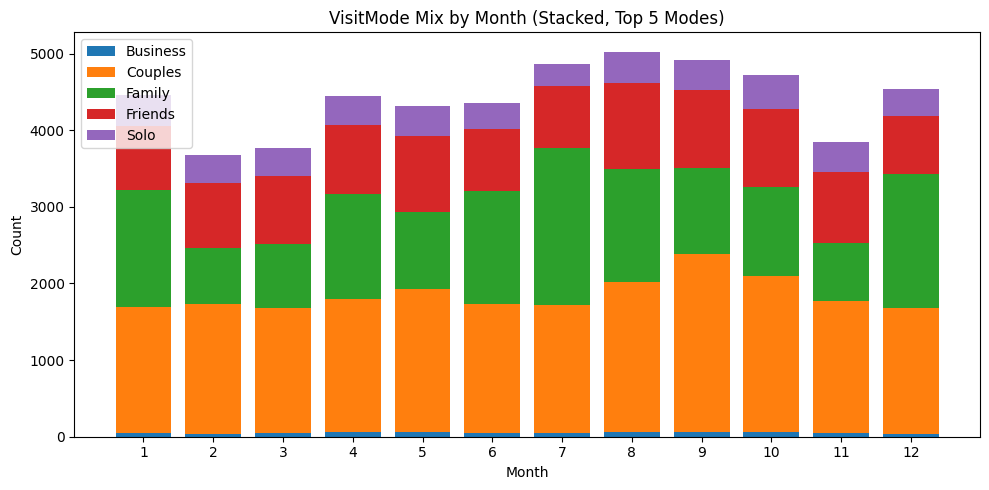

In [21]:
## 10 Stacked bar: VisitMode distribution by Month (top 5 modes)
if "VisitMonth" in df.columns and "VisitMode" in df.columns:
    d = df.dropna(subset=["VisitMonth","VisitMode"]).copy()
    d["VisitMonth"] = d["VisitMonth"].astype(int)

    top_modes = d["VisitMode"].value_counts().head(5).index
    d = d[d["VisitMode"].isin(top_modes)]

    ctab = pd.crosstab(d["VisitMonth"], d["VisitMode"]).sort_index()
    ctab = ctab.reindex(range(1,13), fill_value=0)

    plt.figure(figsize=(10,5))
    bottom = np.zeros(len(ctab.index))
    for col in ctab.columns:
        plt.bar(ctab.index, ctab[col].values, bottom=bottom, label=str(col))
        bottom += ctab[col].values

    plt.title("VisitMode Mix by Month (Stacked, Top 5 Modes)")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.xticks(range(1,13))
    plt.legend()
    plt.tight_layout()
    plt.show()

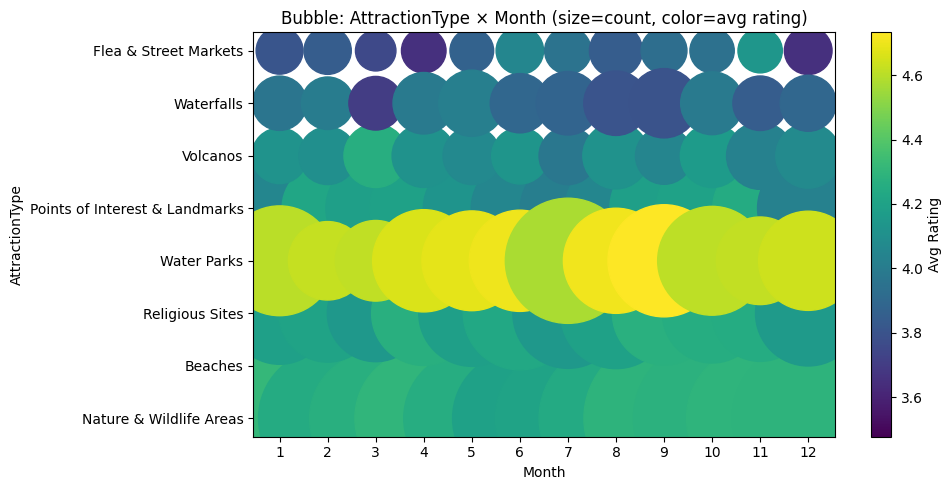

In [22]:
## 11 Bubble chart: AttractionType vs Month with bubble size = count, color = avg rating
if "VisitMonth" in df.columns and "AttractionType" in df.columns and "Rating" in df.columns:
    d = df.dropna(subset=["VisitMonth","AttractionType","Rating"]).copy()
    d["VisitMonth"] = d["VisitMonth"].astype(int)

    # keep top 8 attraction types for readability
    top_types = d["AttractionType"].value_counts().head(8).index
    d = d[d["AttractionType"].isin(top_types)]

    grp = d.groupby(["AttractionType","VisitMonth"]).agg(
        cnt=("Rating","size"),
        avg=("Rating","mean")
    ).reset_index()

    # map attraction type to numeric y positions
    type_to_y = {t:i for i,t in enumerate(top_types)}
    grp["y"] = grp["AttractionType"].map(type_to_y)

    plt.figure(figsize=(10,5))
    sc = plt.scatter(grp["VisitMonth"], grp["y"], s=grp["cnt"]*10, c=grp["avg"])
    plt.title("Bubble: AttractionType × Month (size=count, color=avg rating)")
    plt.xlabel("Month")
    plt.ylabel("AttractionType")
    plt.yticks(ticks=list(type_to_y.values()), labels=[str(t) for t in top_types])
    plt.xticks(range(1,13))
    plt.colorbar(sc, label="Avg Rating")
    plt.tight_layout()
    plt.show()

## 4. Model training

### PART 1 — Regression (Predict Rating) & Evaluation

In [23]:
## Regression training + evaluation (multiple models)
# Target
if "Rating" not in df.columns:
    raise ValueError("Rating column missing. Regression needs Rating.")

# Features for regression (exclude IDs that leak too directly)
drop_cols = ["Rating", "TransactionId"]  # keep UserId/AttractionId if you want, but it can overfit
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["Rating"].astype(float)

# Identify column types
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)

models = {
    "BaselineMean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
best_model = None
best_rmse = float("inf")

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    ## rmse = mean_squared_error(y_test, preds, squared=False)
    rmse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append([name, rmse, mae, r2])
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = pipe

pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"]).sort_values("RMSE")

,Model,RMSE,MAE,R2
3,GradientBoosting,0.236257,0.264200,0.749148
1,LinearRegression,0.247340,0.289659,0.737379
2,RandomForest,0.282296,0.256071,0.700264
0,BaselineMean,0.941818,0.759383,-0.000002


In [24]:
## Save best regression model
os.makedirs("/content/drive/MyDrive/tourism_project/artifacts", exist_ok=True)
joblib.dump(best_model, "/content/drive/MyDrive/tourism_project/artifacts/rating_regression_model.joblib")
print("Saved:", "/content/drive/MyDrive/tourism_project/artifacts/rating_regression_model.joblib")

Saved: /content/drive/MyDrive/tourism_project/artifacts/rating_regression_model.joblib


### PART 2 — Classification (Predict Visit Mode) & Evaluation

In [25]:
## Classification training + evaluation
if "VisitMode" not in df.columns:
    raise ValueError("VisitMode column missing. Classification needs VisitMode.")

# For predicting VisitMode, remove VisitMode and remove Rating (to avoid leakage)
drop_cols_cls = ["VisitMode", "TransactionId", "Rating"]
Xc = df.drop(columns=[c for c in drop_cols_cls if c in df.columns])
yc = df["VisitMode"].astype(str)

categorical_features_c = Xc.select_dtypes(include=["object"]).columns.tolist()
numeric_features_c = [c for c in Xc.columns if c not in categorical_features_c]

preprocess_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features_c),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features_c),
    ]
)

models_c = {
    "BaselineMostFreq": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=200, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

results_c = []
best_clf = None
best_f1 = -1

for name, model in models_c.items():
    pipe = Pipeline(steps=[("preprocess", preprocess_c), ("model", model)])
    pipe.fit(Xc_train, yc_train)
    preds = pipe.predict(Xc_test)
    acc = accuracy_score(yc_test, preds)
    f1 = f1_score(yc_test, preds, average="macro")
    results_c.append([name, acc, f1])
    if f1 > best_f1:
        best_f1 = f1
        best_clf = pipe

pd.DataFrame(results_c, columns=["Model", "Accuracy", "MacroF1"]).sort_values("MacroF1", ascending=False)

,Model,Accuracy,MacroF1
2,RandomForest,0.523238,0.423752
3,GradientBoosting,0.482052,0.295704
1,LogisticRegression,0.401568,0.152070
0,BaselineMostFreq,0.408464,0.116003


              precision    recall  f1-score   support

    Business       0.51      0.26      0.34       125
     Couples       0.52      0.76      0.62      4324
      Family       0.55      0.48      0.51      3043
     Friends       0.46      0.27      0.34      2189
        Solo       0.58      0.21      0.31       905

    accuracy                           0.52     10586
   macro avg       0.52      0.39      0.42     10586
weighted avg       0.52      0.52      0.50     10586



<Figure size 640x480 with 0 Axes>

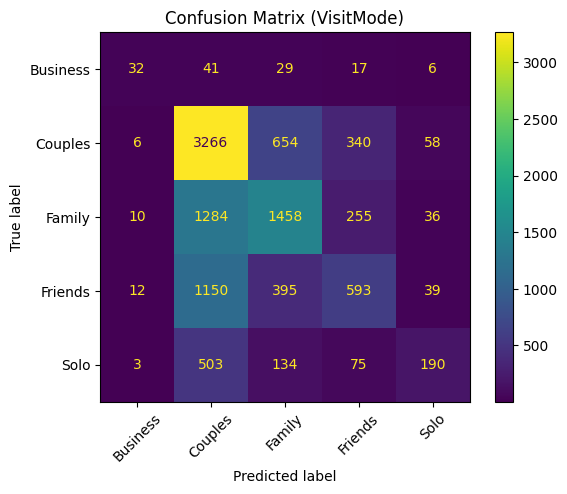

Saved: /content/drive/MyDrive/tourism_project/artifacts/visitmode_classifier.joblib


In [26]:
## Classification report + confusion matrix + save model
preds_best = best_clf.predict(Xc_test)
print(classification_report(yc_test, preds_best))

plt.figure()
ConfusionMatrixDisplay.from_predictions(yc_test, preds_best, xticks_rotation=45)
plt.title("Confusion Matrix (VisitMode)")
plt.show()

joblib.dump(best_clf, "/content/drive/MyDrive/tourism_project/artifacts/visitmode_classifier.joblib")
print("Saved:", "/content/drive/MyDrive/tourism_project/artifacts/visitmode_classifier.joblib")

### PART 3 — Recommendation System

In [27]:
## Collaborative Filtering (User-Item) recommender
# Need user, attraction, rating
rec_df = df[["UserId", "AttractionId", "Rating"]].dropna().copy()
rec_df["UserId"] = rec_df["UserId"].astype(int)
rec_df["AttractionId"] = rec_df["AttractionId"].astype(int)

user_item = rec_df.pivot_table(index="UserId", columns="AttractionId", values="Rating", aggfunc="mean").fillna(0)

# Item-item similarity (cosine)
item_sim = cosine_similarity(user_item.T)
item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

def recommend_collab(user_id, top_n=10):
    if user_id not in user_item.index:
        return pd.DataFrame({"AttractionId": [], "score": []})

    user_ratings = user_item.loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()
    if len(rated_items) == 0:
        # Cold start: recommend top-rated attractions
        top = rec_df.groupby("AttractionId")["Rating"].mean().sort_values(ascending=False).head(top_n)
        return top.reset_index().rename(columns={"Rating": "score"})

    # Score candidate items by similarity weighted by user ratings
    scores = item_sim_df[rated_items].dot(user_ratings[rated_items])
    scores = scores.drop(rated_items, errors="ignore").sort_values(ascending=False).head(top_n)
    return scores.reset_index().rename(columns={0: "score", "index": "AttractionId"})

# Test
sample_user = user_item.index[0]
recommend_collab(sample_user, top_n=10).head()

,AttractionId,score
0,749,1.717209
1,737,1.048467
2,824,0.952040
3,841,0.779154
4,673,0.755291


In [28]:
## Content-Based recommender (based on attraction features)
# Build item feature table
item_cols = ["AttractionId"]
for c in ["AttractionType", "AttractionCityName", "CountryId", "RegionId", "ContinentId"]:
    if c in df.columns:
        item_cols.append(c)

items_feat = df[item_cols].drop_duplicates("AttractionId").copy()
items_feat = items_feat.fillna("Unknown")

# One-hot encode item features
cat_item = items_feat.select_dtypes(include=["object"]).columns.tolist()
num_item = [c for c in items_feat.columns if c not in cat_item and c != "AttractionId"]

ct_item = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_item),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_item),
    ]
)

item_matrix = ct_item.fit_transform(items_feat.drop(columns=["AttractionId"]))
content_sim = cosine_similarity(item_matrix)
content_sim_df = pd.DataFrame(content_sim, index=items_feat["AttractionId"], columns=items_feat["AttractionId"])

def recommend_similar_items(attraction_id, top_n=10):
    if attraction_id not in content_sim_df.index:
        return pd.DataFrame({"AttractionId": [], "sim_score": []})
    sims = content_sim_df.loc[attraction_id].drop(attraction_id).sort_values(ascending=False).head(top_n)
    return sims.reset_index().rename(columns={"index": "AttractionId", attraction_id: "sim_score"})

# Test
sample_item = items_feat["AttractionId"].iloc[0]
recommend_similar_items(sample_item, top_n=10).head()

,AttractionId,sim_score
0,481,0.999963
1,749,0.999963
2,737,0.999963
3,748,0.999963
4,1171,0.999926


In [29]:
## Hybrid recommender (collab + content)
def recommend_hybrid(user_id, top_n=10, alpha=0.7):
    """
    alpha: weight for collaborative scores; (1-alpha) for content-based
    """
    collab = recommend_collab(user_id, top_n=200)
    if collab.empty:
        return collab

    # Normalize collaborative scores
    collab_scores = collab.set_index("AttractionId")["score"]
    collab_scores = (collab_scores - collab_scores.min()) / (collab_scores.max() - collab_scores.min() + 1e-9)

    # Content boost: items similar to what the user liked
    if user_id in user_item.index:
        user_ratings = user_item.loc[user_id]
        liked = user_ratings[user_ratings >= user_ratings[user_ratings > 0].mean()].index.tolist()
    else:
        liked = []

    content_scores = pd.Series(0.0, index=collab_scores.index)
    for it in liked[:5]:
        if it in content_sim_df.index:
            sims = content_sim_df.loc[it]
            sims = sims.reindex(content_scores.index).fillna(0)
            content_scores += sims

    if content_scores.max() > 0:
        content_scores = content_scores / content_scores.max()

    final = alpha * collab_scores + (1 - alpha) * content_scores
    final = final.sort_values(ascending=False).head(top_n)

    return final.reset_index().rename(columns={"index": "AttractionId", 0: "final_score"})

recommend_hybrid(sample_user, top_n=10)

,AttractionId,final_score
0,749,1.000000
1,737,0.727395
2,824,0.688070
3,841,0.617588
4,673,0.607861
5,650,0.602218
6,369,0.563574
7,481,0.540963
8,1166,0.347708
9,888,0.342653


In [30]:
## Save recommender artifacts

#ARTIFACT_DIR = "/content/drive/MyDrive/tourism_project/artifacts"
joblib.dump(user_item, "/content/drive/MyDrive/tourism_project/artifacts/user_item_matrix.joblib")
joblib.dump(item_sim_df, "/content/drive/MyDrive/tourism_project/artifacts/item_similarity_collab.joblib")
joblib.dump(items_feat, "/content/drive/MyDrive/tourism_project/artifacts/items_features.joblib")
joblib.dump(ct_item, "/content/drive/MyDrive/tourism_project/artifacts/items_content_encoder.joblib")
joblib.dump(content_sim_df, "/content/drive/MyDrive/tourism_project/artifacts/item_similarity_content.joblib")

print("Saved recommender artifacts in /content/drive/MyDrive/tourism_project/artifacts/")

Saved recommender artifacts in /content/drive/MyDrive/tourism_project/artifacts/


### PART 4 — SQL queries (DuckDB)

In [31]:
## Run SQL analytics on your consolidated df
con = duckdb.connect()
con.register("tourism", df)

# Example queries
q1 = """
SELECT AttractionId, AVG(Rating) AS avg_rating, COUNT(*) AS n
FROM tourism
WHERE Rating IS NOT NULL
GROUP BY AttractionId
HAVING COUNT(*) >= 5
ORDER BY avg_rating DESC
LIMIT 10;
"""

q2 = """
SELECT VisitMode, COUNT(*) AS visits
FROM tourism
GROUP BY VisitMode
ORDER BY visits DESC;
"""

print("Top attractions by avg rating:")
display(con.execute(q1).df())

print("VisitMode distribution:")
display(con.execute(q2).df())

Top attractions by avg rating:


,AttractionId,avg_rating,n
0,947,4.698795,83
1,841,4.646601,6429
2,888,4.611549,381
3,928,4.571429,28
4,1133,4.503704,135
5,920,4.318182,44
6,481,4.275665,2104
7,640,4.267086,13198
8,1278,4.256646,978
9,824,4.219411,3359


VisitMode distribution:


,VisitMode,visits
0,Couples,21620
1,Family,15217
2,Friends,10945
3,Solo,4525
4,Business,623


## Deployment ( Streamlit App)